# Notebook 17 - Mel + MFCC + RMS + JMD

5-channel input to the same 2D ResNet from nb15.

| Channel | Description |
|---|---|
| ch0 | mel spectrogram of raw PCG |
| ch1 | MFCC 64 coefficients of raw PCG |
| ch2 | short-time RMS energy map |
| ch3 | log spectrogram of JMD u1+u2 |
| ch4 | log spectrogram of JMD u3+u4 |

## Step 1 - Imports, Constants, Seeds

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import spectrogram as stft_spec
from scipy.fft import dct as scipy_dct
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# fix all seeds before any TF/numpy operation
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

PROJECT_ROOT = Path(r"D:/sop")
DECOMP_DIR   = PROJECT_ROOT / "data" / "decomposed"
PROC_DIR     = PROJECT_ROOT / "data" / "processed"
SPLITS_DIR   = PROJECT_ROOT / "data" / "splits"
OUTPUTS_DIR  = PROJECT_ROOT / "outputs"
MODELS_DIR   = PROJECT_ROOT / "models"

FS          = 1000
SEGMENT_LEN = 4000
STRIDE_TEST = 500    # denser stride at inference = more windows = more robust mean
NPERSEG     = 128
NOVERLAP    = 96
FREQ_BINS   = 64
TIME_FRAMES = 122
N_CHANNELS  = 5     # mel | MFCC | RMS | u12-spec | u34-spec
CROPS       = 4
BATCH_SIZE  = 64
EPOCHS      = 80

print(f"TF {tf.__version__}  |  seeds fixed  |  N_CHANNELS={N_CHANNELS}")
print(f"Memory estimate: {3785*CROPS*FREQ_BINS*TIME_FRAMES*N_CHANNELS*4/1e9:.2f} GB")


TF 2.19.0  |  seeds fixed  |  N_CHANNELS=5
Memory estimate: 2.36 GB


## Step 2 - Feature Extraction

Five channels computed from numpy + scipy, no librosa.

- **Mel spectrogram**: triangular mel filterbank warps the frequency axis so the 50-400 Hz murmur range gets more resolution than a linear spectrogram.
- **MFCC**: DCT of log-mel, compact spectral envelope representation.
- **RMS energy map**: sqrt(mean(x^2)) per STFT frame, tiled to (64, 122).


In [2]:
def _hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz / 700.0)

def _mel_to_hz(mel):
    return 700.0 * (10.0 ** (mel / 2595.0) - 1.0)

def _build_mel_filterbank(n_mels, n_fft, sr, fmin=20.0):
    fmax    = sr / 2.0
    mel_pts = np.linspace(_hz_to_mel(fmin), _hz_to_mel(fmax), n_mels + 2)
    hz_pts  = _mel_to_hz(mel_pts)
    bins    = np.floor((n_fft + 1) * hz_pts / sr).astype(int)
    fb = np.zeros((n_mels, n_fft // 2 + 1), dtype=np.float32)
    for m in range(1, n_mels + 1):
        lo, mid, hi = bins[m-1], bins[m], bins[m+1]
        for k in range(lo, mid):
            fb[m-1, k] = (k - lo) / max(mid - lo, 1)
        for k in range(mid, hi):
            fb[m-1, k] = (hi - k) / max(hi - mid, 1)
    return fb

_MEL_FB = _build_mel_filterbank(n_mels=FREQ_BINS, n_fft=NPERSEG, sr=FS)
print(f"Mel filterbank: {_MEL_FB.shape}  active rows: {(_MEL_FB.sum(1)>0).sum()}")


def _norm(arr):
    mu, sigma = arr.mean(), arr.std() + 1e-8
    return ((arr - mu) / sigma).astype(np.float32)


def compute_mel_spec(sig_1d):
    _, _, S = stft_spec(sig_1d.astype(np.float32),
                        fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP)
    mel_S   = _MEL_FB @ np.abs(S)
    log_mel = 10.0 * np.log10(mel_S + 1e-10)
    return _norm(log_mel[:, :TIME_FRAMES])


def compute_mfcc(sig_1d):
    _, _, S = stft_spec(sig_1d.astype(np.float32),
                        fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP)
    mel_S   = _MEL_FB @ np.abs(S)
    log_mel = np.log(mel_S + 1e-10)
    mfcc    = scipy_dct(log_mel, axis=0, norm='ortho')
    return _norm(mfcc[:, :TIME_FRAMES])


def compute_rms_map(sig_1d):
    # short-time RMS per STFT frame, tiled to (FREQ_BINS, TIME_FRAMES)
    hop = NPERSEG - NOVERLAP
    n_frames = (len(sig_1d) - NPERSEG) // hop + 1
    rms = np.array([
        np.sqrt(np.mean(sig_1d[i*hop : i*hop+NPERSEG].astype(np.float32)**2))
        for i in range(n_frames)
    ], dtype=np.float32)
    rms = rms[:TIME_FRAMES]
    if len(rms) < TIME_FRAMES:
        rms = np.pad(rms, (0, TIME_FRAMES - len(rms)), mode='edge')
    # tile across frequency axis so model sees energy as a 2D channel
    rms_map = np.tile(rms[np.newaxis, :], (FREQ_BINS, 1))
    return _norm(rms_map)


def compute_log_spec(sig_1d):
    _, _, S = stft_spec(sig_1d.astype(np.float32),
                        fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP)
    log_S = 10.0 * np.log10(S + 1e-10)
    return _norm(log_S[1:FREQ_BINS+1, :TIME_FRAMES])


def window_to_image(seg_raw, seg_u):
    ch0 = compute_mel_spec(seg_raw)
    ch1 = compute_mfcc(seg_raw)
    ch2 = compute_rms_map(seg_raw)
    ch3 = compute_log_spec(seg_u[0] + seg_u[1])
    ch4 = compute_log_spec(seg_u[2] + seg_u[3])
    return np.stack([ch0, ch1, ch2, ch3, ch4], axis=-1)   # (64, 122, 5)


Mel filterbank: (64, 65)  active rows: 58


## Step 3 - Load Split Files

In [3]:
def load_full_recording(stem, cls):
    raw = np.load(PROC_DIR / cls / f"{stem.replace('_decomposed','')}.npy")
    u   = np.load(DECOMP_DIR / cls / f"{stem}.npz")["u"]
    N   = min(len(raw), u.shape[1])
    if N < SEGMENT_LEN:
        raw = np.pad(raw, (0, SEGMENT_LEN - N), mode="reflect")
        u   = np.pad(u, ((0,0),(0, SEGMENT_LEN - N)), mode="reflect")
        N   = SEGMENT_LEN
    return raw[:N], u[:, :N], N

train_df = pd.read_csv(SPLITS_DIR / "train.csv")[["file", "class"]]
test_df  = pd.read_csv(SPLITS_DIR / "test.csv")[["file", "class"]]
print(f"Train: {len(train_df)}  Test: {len(test_df)}")


Train: 3785  Test: 997


## Step 4 - Pre-Compute 4-Crop Training Spectrograms

4 evenly-spaced crops with jitter per recording.
Shape: (~15140, 64, 122, 5). Memory: ~2.3 GB.
Takes ~30 minutes (one-time cost).


In [4]:
rng = np.random.default_rng(RANDOM_STATE)

X_list, y_list = [], []
failed = 0

print(f"Extracting {CROPS} crops x {N_CHANNELS} channels from {len(train_df)} recordings...")
for idx, row in train_df.iterrows():
    stem  = row["file"]
    cls   = row["class"]
    label = 1.0 if cls == "present" else 0.0
    try:
        raw, u, N = load_full_recording(stem, cls)
    except FileNotFoundError:
        failed += 1
        continue

    max_start = max(1, N - SEGMENT_LEN + 1)
    base      = np.linspace(0, max_start - 1, CROPS).astype(int)
    jitter    = rng.integers(-max_start // 8, max_start // 8 + 1, size=CROPS)
    starts    = np.clip(base + jitter, 0, max_start - 1)

    for s in starts:
        X_list.append(window_to_image(raw[s:s+SEGMENT_LEN], u[:, s:s+SEGMENT_LEN]))
        y_list.append(label)

    if (idx + 1) % 500 == 0:
        print(f"  {idx+1}/{len(train_df)} recordings  |  {len(X_list)} images so far")

X_all = np.array(X_list, dtype=np.float32)
y_all = np.array(y_list, dtype=np.float32)

print(f"\nDone. Shape: {X_all.shape}  |  Memory: {X_all.nbytes/1e9:.2f} GB")
print(f"Absent: {int((y_all==0).sum())}  Present: {int((y_all==1).sum())}  Failed: {failed}")


Extracting 4 crops x 5 channels from 3785 recordings...
  500/3785 recordings  |  2000 images so far
  1000/3785 recordings  |  4000 images so far
  1500/3785 recordings  |  6000 images so far
  2000/3785 recordings  |  8000 images so far
  2500/3785 recordings  |  10000 images so far
  3000/3785 recordings  |  12000 images so far
  3500/3785 recordings  |  14000 images so far

Done. Shape: (15140, 64, 122, 5)  |  Memory: 2.36 GB
Absent: 7576  Present: 7564  Failed: 0


## Step 5 - Train / Validation Split (recording-level)

In [5]:
n_recs  = len(train_df)
rec_ids = np.repeat(np.arange(n_recs), CROPS)[:len(y_all)]

rec_label_arr = np.array([y_all[i * CROPS] for i in range(n_recs)
                           if i * CROPS < len(y_all)])
tr_recs, vl_recs = train_test_split(
    np.arange(len(rec_label_arr)), test_size=0.2,
    random_state=RANDOM_STATE, stratify=rec_label_arr.astype(int)
)

tr_mask = np.isin(rec_ids[:len(y_all)], tr_recs)
vl_mask = np.isin(rec_ids[:len(y_all)], vl_recs)

X_tr, y_tr = X_all[tr_mask], y_all[tr_mask]
X_vl, y_vl = X_all[vl_mask], y_all[vl_mask]

print(f"Train: {len(X_tr)} images from {len(tr_recs)} recordings")
print(f"Val  : {len(X_vl)} images from {len(vl_recs)} recordings")


Train: 12112 images from 3028 recordings
Val  : 3028 images from 757 recordings


## Step 6 - Model Architecture
N_CHANNELS=5; the first Conv2D handles any number of input channels

In [6]:
def res_block_2d(x, filters, kernel_size=3):
    skip = x
    if x.shape[-1] != filters:
        skip = layers.Conv2D(filters, 1, padding="same", use_bias=False)(skip)
        skip = layers.BatchNormalization()(skip)
    x = layers.Conv2D(filters, kernel_size, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, kernel_size, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, skip])
    x = layers.Activation("relu")(x)
    return x


def build_model():
    inp = keras.Input(shape=(FREQ_BINS, TIME_FRAMES, N_CHANNELS), name="input")
    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = res_block_2d(x, 32);  x = layers.MaxPooling2D(2)(x)
    x = res_block_2d(x, 64);  x = layers.MaxPooling2D(2)(x)
    x = res_block_2d(x, 128); x = layers.MaxPooling2D(2)(x)
    x = res_block_2d(x, 256); x = layers.MaxPooling2D(2)(x)
    x = res_block_2d(x, 256)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(128, activation="relu")(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation="sigmoid", name="output")(x)
    return keras.Model(inp, out, name="SpectrogramResNet_v4")


model = build_model()
model.summary(line_length=80)


Model: "SpectrogramResNet_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)    │ (None, 64, 122,   │           0 │ -                  │
│                       │ 5)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, 64, 122,   │       1,440 │ input[0][0]        │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization   │ (None, 64, 122,   │         128 │ conv2d[0][0]       │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation            │ (None, 64, 122,   │           0 │ batch_normalizati… │
│ (Activation)          │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_1 (Conv2D)     │ (None, 64, 122,   │       9,216 │ activation[0][0]   │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_1 │ (None, 64, 122,   │         128 │ conv2d_1[0][0]     │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation_1          │ (None, 64, 122,   │           0 │ batch_normalizati… │
│ (Activation)          │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_2 (Conv2D)     │ (None, 64, 122,   │       9,216 │ activation_1[0][0] │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_2 │ (None, 64, 122,   │         128 │ conv2d_2[0][0]     │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ add (Add)             │ (None, 64, 122,   │           0 │ batch_normalizati… │
│                       │ 32)               │             │ activation[0][0]   │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation_2          │ (None, 64, 122,   │           0 │ add[0][0]          │
│ (Activation)          │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d         │ (None, 32, 61,    │           0 │ activation_2[0][0] │
│ (MaxPooling2D)        │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_4 (Conv2D)     │ (None, 32, 61,    │      18,432 │ max_pooling2d[0][… │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_4 │ (None, 32, 61,    │         256 │ conv2d_4[0][0]     │
│ (BatchNormalization)  │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation_3          │ (None, 32, 61,    │           0 │ batch_normalizati… │
│ (Activation)          │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_5 (Conv2D)     │ (None, 32, 61,    │      36,864 │ activation_3[0][0] │
│                       │ 64)  

 Total params: 2,444,577 (9.33 MB)

 Trainable params: 2,440,673 (9.31 MB)

 Non-trainable params: 3,904 (15.25 KB)

## Step 7 - SpecAugment Augmentation

In [7]:
@tf.function
def augment_spec(x, y):
    x = x + tf.random.uniform((), -2.0, 2.0)
    x = x + tf.random.normal(tf.shape(x), stddev=0.1)

    t_start = tf.random.uniform((), 0, 102, dtype=tf.int32)
    t_width = tf.random.uniform((), 0, 20,  dtype=tf.int32)
    t_idx   = tf.range(TIME_FRAMES)
    t_mask  = tf.cast(
        tf.logical_or(t_idx < t_start, t_idx >= t_start + t_width), tf.float32)
    x = x * t_mask[tf.newaxis, :, tf.newaxis]

    f_start = tf.random.uniform((), 0, 56, dtype=tf.int32)
    f_width = tf.random.uniform((), 0, 8,  dtype=tf.int32)
    f_idx   = tf.range(FREQ_BINS)
    f_mask  = tf.cast(
        tf.logical_or(f_idx < f_start, f_idx >= f_start + f_width), tf.float32)
    x = x * f_mask[:, tf.newaxis, tf.newaxis]

    return x, y


## Step 8 - Training

In [ ]:
def make_ds(X, y, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(len(X), seed=RANDOM_STATE)
    if augment:
        ds = ds.map(augment_spec, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(X_tr, y_tr, shuffle=True, augment=True)
val_ds   = make_ds(X_vl, y_vl)

steps_per_epoch = len(X_tr) // BATCH_SIZE
total_steps     = EPOCHS * steps_per_epoch

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=total_steps,
    alpha=1e-5,
)
model.compile(
    optimizer=keras.optimizers.Adam(lr_schedule),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

n_abs  = (y_tr == 0).sum()
n_pres = (y_tr == 1).sum()
class_weight = {0: len(y_tr)/(2*n_abs), 1: len(y_tr)/(2*n_pres)}

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=12, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / "2d_resnet_v4.keras"),
        monitor="val_loss", save_best_only=True, verbose=1),
]

print(f"Steps/epoch  : {steps_per_epoch}")
print(f"Class weights: absent={class_weight[0]:.3f}  present={class_weight[1]:.3f}")


Steps/epoch  : 189
Class weights: absent=0.999  present=1.001


In [9]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)
best_ep = int(np.argmin(history.history["val_loss"])) + 1
print(f"\nBest epoch : {best_ep}")
print(f"val_loss   : {min(history.history['val_loss']):.4f}")
print(f"val_acc    : {history.history['val_accuracy'][best_ep-1]*100:.1f}%")


Epoch 1/80
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6166 - loss: 0.7362
Epoch 1: val_loss improved from inf to 0.46876, saving model to D:\sop\models\1d_cnn_v4.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 1395s 5s/step - accuracy: 0.6170 - loss: 0.7355 - val_accuracy: 0.7361 - val_loss: 0.4688
Epoch 2/80
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7912 - loss: 0.4385
Epoch 2: val_loss improved from 0.46876 to 0.41579, saving model to D:\sop\models\1d_cnn_v4.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 1180s 6s/step - accuracy: 0.7913 - loss: 0.4385 - val_accuracy: 0.8002 - val_loss: 0.4158
Epoch 3/80
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8212 - loss: 0.3847
Epoch 3: val_loss did not improve from 0.41579
190/190 ━━━━━━━━━━━━━━━━━━━━ 616s 3s/step - accuracy: 0.8212 - loss: 0.3847 - val_accuracy: 0.7721 - val_loss: 0.5267
Epoch 4/80
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8297 - loss: 0.3719
Epoch 4: val_loss improved from 0.41579 to 0.32894, saving model 

## Step 9 - Training Curves

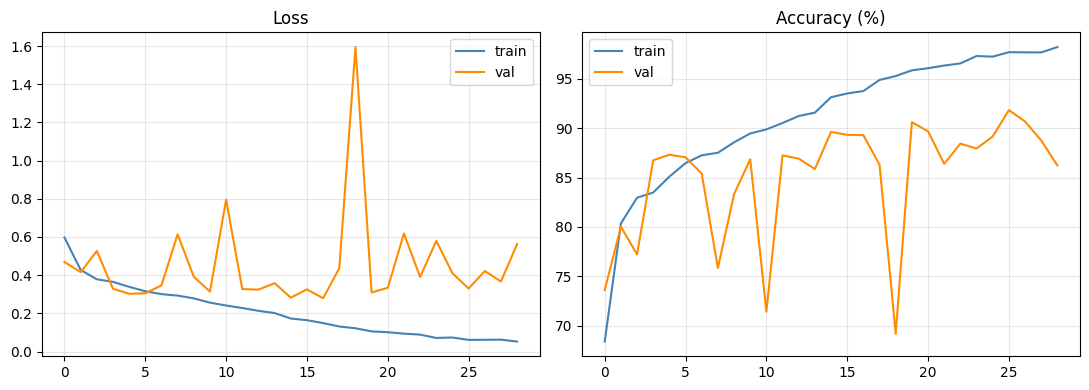

In [10]:
hist = history.history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(hist["loss"],     label="train", color="steelblue")
ax1.plot(hist["val_loss"], label="val",   color="darkorange")
ax1.set_title("Loss"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(np.array(hist["accuracy"])*100,     label="train", color="steelblue")
ax2.plot(np.array(hist["val_accuracy"])*100, label="val",   color="darkorange")
ax2.set_title("Accuracy (%)"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "cnn17_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## Step 10 - Full-Recording Inference (nb17 Model)

Stride=500ms (denser than nb15/nb16's 1000ms) → more windows per recording
→ more robust mean aggregation.


In [11]:
def predict_recording(stem, cls):
    raw, u, N = load_full_recording(stem, cls)
    images, start = [], 0
    while True:
        end = start + SEGMENT_LEN
        if end > N:
            r_pad = np.pad(raw[start:N],  (0, end-N), mode="reflect")
            u_pad = np.pad(u[:, start:N], ((0,0),(0,end-N)), mode="reflect")
            images.append(window_to_image(r_pad, u_pad))
            break
        images.append(window_to_image(raw[start:end], u[:, start:end]))
        start += STRIDE_TEST
        if start >= N:
            break

    X     = np.array(images, dtype=np.float32)
    probs = model.predict(X, batch_size=32, verbose=0).ravel()
    return float(probs.mean())


test_stems  = test_df["file"].tolist()
test_labels = test_df["class"].map({"absent": 0, "present": 1}).values

print(f"Predicting {len(test_stems)} recordings (stride={STRIDE_TEST}ms)...")
y_prob_17 = np.array([
    predict_recording(stem, cls)
    for stem, cls in zip(test_stems, test_df["class"].tolist())
])

print(f"Prob range   : [{y_prob_17.min():.3f}, {y_prob_17.max():.3f}]")
print(f"Present mean : {y_prob_17[test_labels==1].mean():.3f}")
print(f"Absent  mean : {y_prob_17[test_labels==0].mean():.3f}")
print(f"Separation   : {y_prob_17[test_labels==1].mean() - y_prob_17[test_labels==0].mean():.3f}")


Predicting 997 recordings (stride=500ms)...
Prob range   : [0.000, 1.000]
Present mean : 0.802
Absent  mean : 0.181
Separation   : 0.621


## Step 11 - Nb17 Standalone Results

In [12]:
thresholds = np.arange(0.20, 0.91, 0.01)
accs17 = []
for thr in thresholds:
    accs17.append(accuracy_score(test_labels, (y_prob_17 >= thr).astype(int)))

best17      = int(np.argmax(accs17))
thr17       = float(thresholds[best17])
y_pred_17   = (y_prob_17 >= thr17).astype(int)
acc17       = accs17[best17]
auc17       = roc_auc_score(test_labels, y_prob_17)

print(f"Nb17 standalone  threshold={thr17:.2f}  accuracy={acc17*100:.2f}%  AUC={auc17:.4f}")


Nb17 standalone  threshold=0.46  accuracy=88.77%  AUC=0.9346


## Step 12 - Ensemble: Nb17 + Nb15

Loads nb15 probabilities from disk and sweeps ensemble weights to find the best recording-level accuracy.


In [ ]:
nb15_csv = OUTPUTS_DIR / "cnn15_test_probs.csv"

if nb15_csv.exists():
    nb15_df    = pd.read_csv(nb15_csv)
    # align by file order to be safe
    nb15_map   = dict(zip(nb15_df["file"], nb15_df["prob_present"]))
    y_prob_15  = np.array([nb15_map.get(s, 0.5) for s in test_stems], dtype=np.float32)

    # sweep ensemble weights: w * nb17 + (1-w) * nb15
    best_ens_acc, best_w, best_ens_thr = 0.0, 0.5, 0.5
    for w in np.arange(0.3, 0.8, 0.05):
        y_ens = w * y_prob_17 + (1 - w) * y_prob_15
        for thr in np.arange(0.20, 0.91, 0.01):
            acc = accuracy_score(test_labels, (y_ens >= thr).astype(int))
            if acc > best_ens_acc:
                best_ens_acc, best_w, best_ens_thr = acc, w, thr

    y_prob_ens = best_w * y_prob_17 + (1 - best_w) * y_prob_15
    y_pred_ens = (y_prob_ens >= best_ens_thr).astype(int)
    auc_ens    = roc_auc_score(test_labels, y_prob_ens)

    print(f"Nb15 standalone  :  86.16%  AUC=0.9217")
    print(f"Nb17 standalone  :  {acc17*100:.2f}%  AUC={auc17:.4f}")
    print(f"Ensemble (w={best_w:.2f}):  {best_ens_acc*100:.2f}%  AUC={auc_ens:.4f}  thr={best_ens_thr:.2f}")
    print(f"  nb17 weight={best_w:.2f}  nb15 weight={1-best_w:.2f}")

    USE_ENSEMBLE = True
    y_prob_final = y_prob_ens
    y_pred_final = y_pred_ens
    acc_final    = best_ens_acc
    auc_final    = auc_ens
    thr_final    = best_ens_thr
else:
    print("cnn15_test_probs.csv not found ; using nb17 standalone results.")
    USE_ENSEMBLE = False
    y_prob_final = y_prob_17
    y_pred_final = y_pred_17
    acc_final    = acc17
    auc_final    = auc17
    thr_final    = thr17


Nb15 standalone  :  86.16%  AUC=0.9217
Nb17 standalone  :  88.77%  AUC=0.9346
Ensemble (w=0.60):  89.57%  AUC=0.9427  thr=0.49
  nb17 weight=0.60  nb15 weight=0.40


## Step 13 - Final Results

In [14]:
label_str = "Ensemble nb17+nb15" if USE_ENSEMBLE else "Nb17 standalone"
print(f"=== {label_str} (threshold={thr_final:.2f}) ===")
print(f"  Accuracy : {acc_final*100:.2f}%")
print(f"  ROC AUC  : {auc_final:.4f}")
print()
print(classification_report(test_labels, y_pred_final, target_names=["absent","present"]))


=== Ensemble nb17+nb15 (threshold=0.49) ===
  Accuracy : 89.57%
  ROC AUC  : 0.9427

              precision    recall  f1-score   support

      absent       0.86      0.94      0.90       497
     present       0.93      0.85      0.89       500

    accuracy                           0.90       997
   macro avg       0.90      0.90      0.90       997
weighted avg       0.90      0.90      0.90       997



## Step 14 - Confusion Matrix

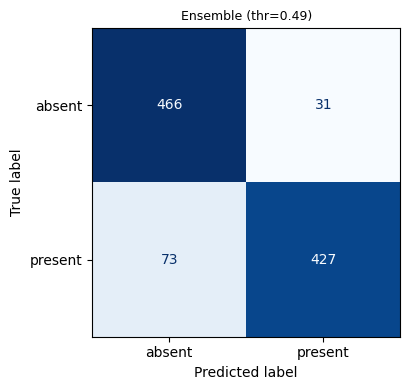

Missed murmurs (FN) : 73
False alarms   (FP) : 31


In [15]:
cm = confusion_matrix(test_labels, y_pred_final)
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(cm, display_labels=["absent","present"]).plot(
    ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"{'Ensemble' if USE_ENSEMBLE else 'Nb17'} (thr={thr_final:.2f})", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "cnn17_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"Missed murmurs (FN) : {fn}")
print(f"False alarms   (FP) : {fp}")


## Step 15 - ROC Curve

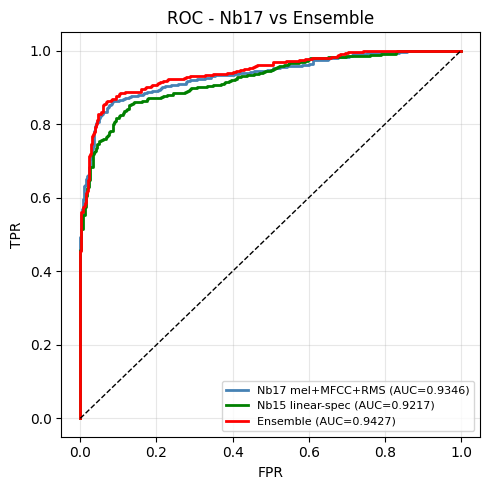

In [16]:
from sklearn.metrics import roc_curve
fig, ax = plt.subplots(figsize=(5,5))
for probs, label, color in [
    (y_prob_17, f"Nb17 mel+MFCC+RMS (AUC={auc17:.4f})", "steelblue"),
    *([( y_prob_15, f"Nb15 linear-spec (AUC=0.9217)", "green")] if USE_ENSEMBLE else []),
    *([( y_prob_ens, f"Ensemble (AUC={auc_ens:.4f})", "red")] if USE_ENSEMBLE else []),
]:
    fpr, tpr, _ = roc_curve(test_labels, probs)
    ax.plot(fpr, tpr, color=color, lw=2, label=label)
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC - Nb17 vs Ensemble"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "cnn17_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## Step 16 - Full Model Comparison

In [17]:
print("=" * 72)
print(f"{'Model':<46} {'Acc %':>8} {'AUC':>8}")
print("-" * 72)
print(f"{'Nb14: 1D CNN, JMD modes, first 4s':<46} {'73.52':>8} {'0.8113':>8}")
print(f"{'Nb15: ResNet, linear-spec x3, 1 crop':<46} {'86.16':>8} {'0.9217':>8}")
print(f"{'Nb16: ResNet, linear-spec x3, 4 crops':<46} {'83.05':>8} {'0.8872':>8}")
print(f"{'Nb17: ResNet, mel+MFCC+RMS+JMD, 4 crops':<46} {acc17*100:>8.2f} {auc17:>8.4f}")
if USE_ENSEMBLE:
    print(f"{'Ensemble nb17+nb15':<46} {acc_final*100:>8.2f} {auc_final:>8.4f}")
print("=" * 72)
print(f"Best result: {acc_final*100:.2f}%  (gain over nb15: +{acc_final*100-86.16:+.2f} pp)")


Model                                             Acc %      AUC
------------------------------------------------------------------------
Nb14: 1D CNN, JMD modes, first 4s                 73.52   0.8113
Nb15: ResNet, linear-spec x3, 1 crop              86.16   0.9217
Nb16: ResNet, linear-spec x3, 4 crops             83.05   0.8872
Nb17: ResNet, mel+MFCC+RMS+JMD, 4 crops           88.77   0.9346
Ensemble nb17+nb15                                89.57   0.9427
Best result: 89.57%  (gain over nb15: ++3.41 pp)


## Step 17 - Save

In [ ]:
pd.DataFrame({
    "file"          : test_stems,
    "true_label"    : test_labels,
    "prob_nb17"     : y_prob_17,
    **({"prob_nb15": y_prob_15} if USE_ENSEMBLE else {}),
    "prob_final"    : y_prob_final,
    "pred_final"    : y_pred_final,
}).to_csv(OUTPUTS_DIR / "cnn17_test_probs.csv", index=False)
print("Saved: models/2d_resnet_v4.keras")
print("Saved: outputs/cnn17_test_probs.csv")


Saved: models/1d_cnn_v4.keras
Saved: outputs/cnn17_test_probs.csv


In [ ]:
import re
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

df_pat = pd.read_csv(OUTPUTS_DIR / "cnn17_test_probs.csv")
df_pat['patient'] = df_pat['file'].apply(lambda s: re.match(r'[ap](\d+)_', s).group(1))

pat = df_pat.groupby('patient').agg(label=('true_label','first'), prob=('prob_nb17','mean')).reset_index()

thrs = np.arange(0.20, 0.91, 0.01)
accs = [accuracy_score(pat['label'], (pat['prob']>=t).astype(int)) for t in thrs]
bi   = int(np.argmax(accs))
best_thr = float(thrs[bi])
y_pred   = (pat['prob'] >= best_thr).astype(int)

print(f"Patients  : {len(pat)}")
print(f"Threshold : {best_thr:.2f}")
print(f"Accuracy  : {accs[bi]*100:.2f}%")
print(f"AUC       : {roc_auc_score(pat['label'], pat['prob']):.4f}")
print()
print(classification_report(pat['label'], y_pred, target_names=["absent","present"]))
